In [ ]:
%pip install pretty_midi torch numpy


In [1]:
import torch
import numpy as np
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

GENERATED_DIR = PROJECT_ROOT / "generated"
GENERATED_DIR.mkdir(exist_ok=True)

from utils import (
    build_id_to_token,
    build_token_to_id,
    generate_and_play_for_temperatures,
    generate_tokens,
)
from model import load_trained_model

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "full_sequences.npz"
CHECKPOINT_PATH = PROJECT_ROOT / "models" / "music_gru_checkpoint.pt"


## 1. Load Trained Model Checkpoint
Load the trained GRU model and all metadata needed for generation.

In [2]:
# Device selection
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS).")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU.")
else:
    device = torch.device("cpu")
    print("Using CPU.")

print("Using device:", device)

# Load trained model
model, SEQ_LEN = load_trained_model(CHECKPOINT_PATH, device)
print("Loaded model from:", CHECKPOINT_PATH)

# Load processed dataset
data = np.load(DATA_PATH, allow_pickle=True)
X_ids = data["X"]
vocab = data["vocab"]  # saved vocab array

print("Loaded data from:", DATA_PATH)
print("  X_ids shape:", X_ids.shape)
print("  vocab shape:", vocab.shape)

Using Apple Silicon GPU (MPS).
Using device: mps
Loaded model from: /Users/catherinembata/music-generation-project/models/music_gru_checkpoint.pt
Loaded data from: /Users/catherinembata/music-generation-project/data/processed/full_sequences.npz
  X_ids shape: (820549, 50)
  vocab shape: (318, 2)


## 2. Rebuild Vocabulary and Duration Mapping
Reconstruct (pitch, duration_bucket) token mappings for converting predictions back to notes.

In [3]:
# vocab is an array of [pitch, bucket] pairs, shape (vocab_size, 2)
id_to_token = build_id_to_token(vocab)
token_to_id = build_token_to_id(id_to_token)


## 3. Generated Samples
Generate melodies at multiple temperatures and play the resulting music.

In [ ]:
results = generate_and_play_for_temperatures(
    model,
    X_ids,
    id_to_token=id_to_token,
    seq_len=SEQ_LEN,
    temps=(0.6, 0.8, 1.0),
    num_tokens=200,
    device=device,
    generated_dir=GENERATED_DIR,
)

results

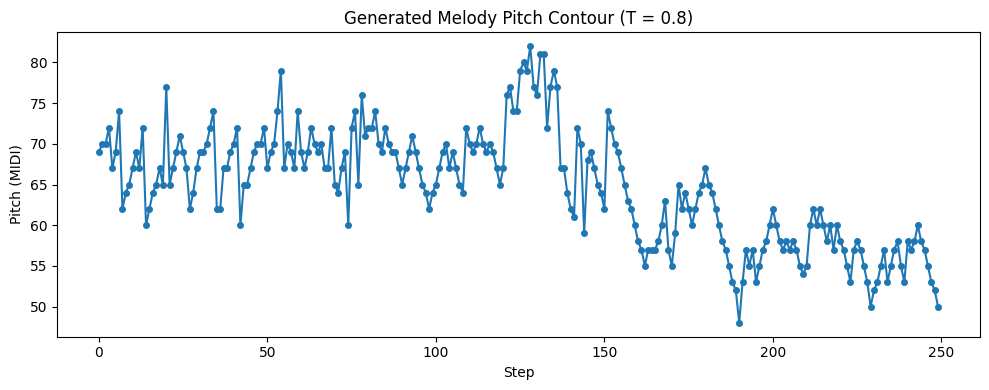

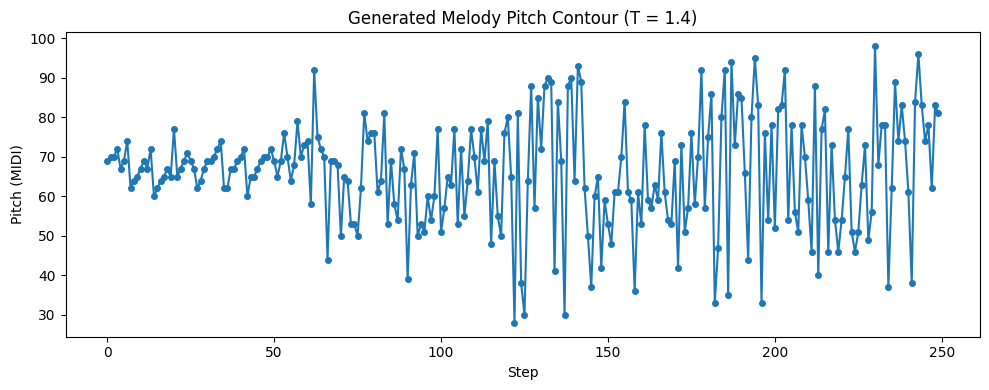

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

seed_seq = X_ids[0] 

temps_to_plot = [0.8, 1.4]

generated_sequences = {}

for temp in temps_to_plot:
    gen_ids = generate_tokens(
        model,
        seed_seq,
        seq_len=SEQ_LEN,
        num_tokens=200,
        temperature=temp,
        device=device
    )
    generated_sequences[temp] = gen_ids

def tokens_to_pitches(tokens, id_to_token):
    return [id_to_token[t][0] for t in tokens]


def plot_pitch_contour(pitches, temp):
    plt.figure(figsize=(10, 4))
    plt.plot(pitches, marker='o', markersize=4)
    plt.title(f"Generated Melody Pitch Contour (T = {temp})")
    plt.xlabel("Step")
    plt.ylabel("Pitch (MIDI)")
    plt.tight_layout()
    plt.show()

for temp in temps_to_plot:
    pitches = tokens_to_pitches(generated_sequences[temp], id_to_token)
    save_path = f"images/pitch_T{str(temp).replace('.', '')}.png"
    plot_pitch_contour(pitches, temp)

## Edge Case Analysis

To evaluate how the model responds to different types of inputs, I generated sequences from four seed configurations: a repeated-note seed, a short consisting of one token, and a random seed.

In [11]:
import numpy as np

# -----------------------------------------------------
# 1) Repeated-note seed
# -----------------------------------------------------
seed_repeated = np.array([60] * 16)

generated_repeated = generate_tokens(
    model,
    seed_seq=seed_repeated,
    seq_len=SEQ_LEN,
    num_tokens=100,
    temperature=1.0,
    device=device
)

# -----------------------------------------------------
# 2) Single-token seed
# -----------------------------------------------------
seed_short1 = np.array([60])

generated_short1 = generate_tokens(
    model,
    seed_seq=seed_short1,
    seq_len=SEQ_LEN,
    num_tokens=100,
    temperature=1.0,
    device=device
)

# -----------------------------------------------------
# 3) Random seed
# -----------------------------------------------------
VOCAB_SIZE = vocab.shape[0]
np.random.seed(42)
random_seed = np.random.randint(0, VOCAB_SIZE, size=16)

generated_random = generate_tokens(
    model,
    seed_seq=random_seed,
    seq_len=SEQ_LEN,
    num_tokens=100,
    temperature=1.0,
    device=device
)

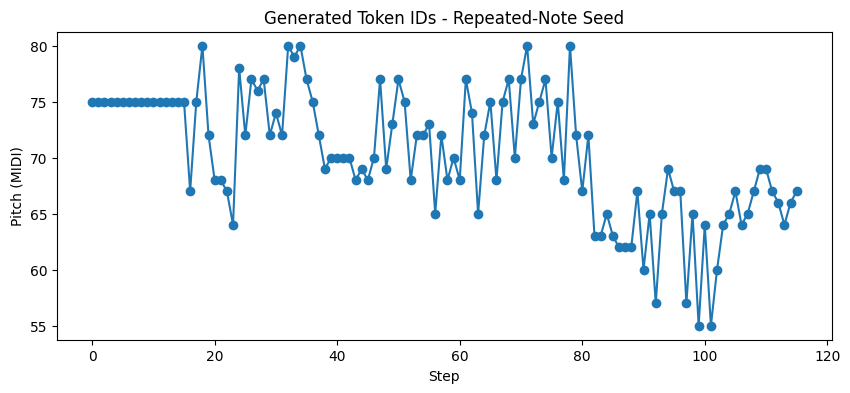

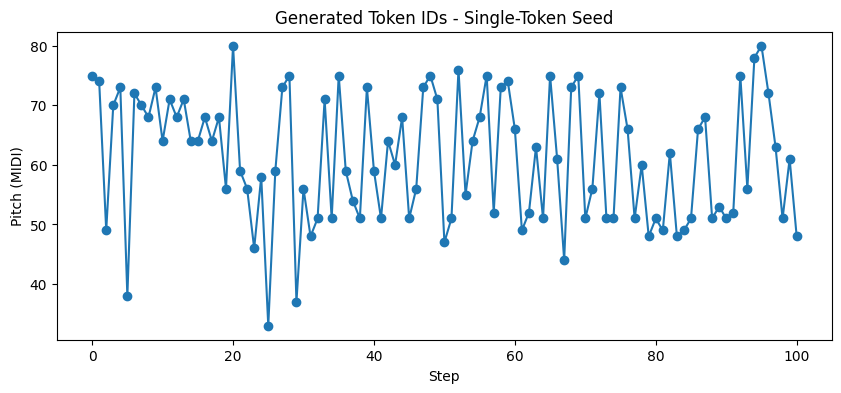

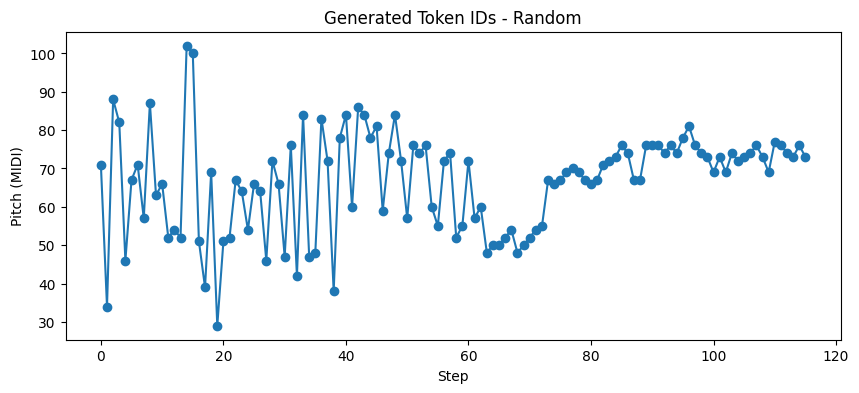

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt

def plot_tokens(tokens, title):
    values = [id_to_token[t][0] for t in tokens]  # extract pitch
    plt.figure(figsize=(10, 4))
    plt.plot(values, marker='o')
    plt.title(title)
    plt.xlabel('Step')
    plt.ylabel("Pitch (MIDI)")
    plt.show()

# 1) Repeated seed
plot_tokens(generated_repeated, 'Generated Token IDs - Repeated-Note Seed')

# 2) Very short seed (1 token)
plot_tokens(generated_short1, 'Generated Token IDs - Single-Token Seed')

# 3) Stress seed (random)
plot_tokens(generated_random, 'Generated Token IDs - Random')

### Analysis

#### Repeated Note Seed: 
The model begins with a flat pitch contour, echoing the seed. Once past the initial context, it drops into a lower register and fluctuates unpredictably, with occasional extreme jumps. No clear stabilization occurs.

#### Very Short Seeds (1-token):
The output is erratic from the start, with wide and frequent pitch swings across registers. The model fails to settle into any consistent melodic pattern, reflecting the insufficiency of the minimal seed.

#### Random Seed:
Initially chaotic, with large pitch swings and no clear structure. However, after ~65 steps, the model stabilizes into a middle register with smaller intervals, suggesting it can recover from noisy input by relying on its own recent outputs.

### Overall Takeways
These patterns indicate that the GRU requires a sufficiently rich and varied context to produce stable melodic output. When the seed is sparse or overly uniform, the model struggles to establish direction and coherence. Enhancing long-range conditioning or integrating positional/contextual cues may help mitigate drift and improve stability, especially in low-information seed scenarios.



## Generation Summary
- The model generates coherent melodic structure when provided with rich, well-formed seed sequences.
- Sparse seeds (repeated‑note or single‑token) fail to stabilize, producing erratic outputs throughout; random seeds begin chaotically but gradually settle into a middle register as the model builds its own context.
- Sampling temperature strongly affects diversity: lower values yield stable, predictable contours, while higher values produce more varied but less coherent sequences.
- Generated examples can be explored interactively in the Streamlit app; this notebook provides visual and analytical evidence of the model’s behavior under different conditions.
